# 05 — Map predicted *Leucadendron argenteum* occurrence and validate it against GBIF

## AVIRIS-NG Level-3 | Table Mountain National Park

This notebook is the final spatial-prediction stage. It follows the standalone hyperspectral classification and the AVIRIS-NG × LVIS integration analyses.

The workflow is:

1. load the **same 324 retained AVIRIS-NG bands** used in the classification notebook;
2. fit the final XGBoost spectral classifier to the complete reference library;
3. predict *L. argenteum* probability for **every valid pixel in every AVIRIS-NG Level-3 mosaic**;
4. combine the predicted tiles into one continuous AVIRIS-NG probability mosaic;
5. clip the completed mosaic to the Table Mountain National Park boundary;
6. create a binary candidate layer for **P > 0.70**;
7. evaluate independent GBIF occurrences against the probability surface.

### Why the base raster is spectral only

The previous mapping workflow required an LVIS canopy value before retaining many predictions. That makes the map inherit the spatial support of the LiDAR rather than the much broader AVIRIS-NG coverage. The base probability surface here therefore uses AVIRIS-NG only. LVIS can still be applied later as a separate structural mask, but it does not decide whether a probability pixel exists.

### What the GBIF validation means

GBIF records are presence-only observations, not verified absences. The comparison therefore measures whether known localities are concentrated in high-probability pixels relative to the rest of the mapped park. It is not presented as an absence-based classification accuracy test.

The strict result is the coincident 5 m pixel. Small 10, 20 and 30 m neighbourhoods are also reported as positional-error sensitivity analyses.

### Final map used for occurrence validation

The primary conservation/search product produced here is the **AVIRIS-NG probability surface after the LVIS RH98 > 14 m veto**. The unfiltered AVIRIS-NG map is retained as a baseline so the effect of the structural constraint can be measured directly.


## 1. Packages, paths and settings

All editable paths are kept here. The defaults follow the directory structure used in the preceding notebooks.

In [1]:
from pathlib import Path
import re
import warnings
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import netCDF4
import rasterio

from rasterio.crs import CRS
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.transform import Affine
from rasterio.warp import calculate_default_transform, reproject, Resampling

from scipy import ndimage
from scipy.spatial import cKDTree

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------
# Project folders
# ---------------------------------------------------------------------

project_root = Path.cwd()

aviris_dir = (
    project_root
    / "Data"
    / "TMNP_AVIRIS_L3"
)

tmnp_path = (
    project_root
    / "Data"
    / "Hyper"
    / "Phemelo_TMNP.shp"
)

hyperspectral_table_dir = (
    project_root
    / "Data"
    / "Hyperspectral"
    / "Outputs_324bands"
    / "Tables"
)

spectral_library_csv = (
    hyperspectral_table_dir
    / "spectral_library_analysis_324bands.csv"
)

retained_bands_csv = (
    hyperspectral_table_dir
    / "retained_bands_324.csv"
)

training_points_csv = (
    project_root
    / "Data"
    / "Hyperspectral"
    / "Outputs"
    / "Species_data_final4.csv"
)


# RH98 raster produced by the preceding AVIRIS-NG × LVIS integration notebook.
# Band 1 contains mean RH98 on the 8 m LVIS footprint-scale grid.
lvis_rh98_raster_path = (
    project_root
    / "outputs"
    / "02_matching_fusion"
    / "rasters"
    / "lvis_rh98_8m.tif"
)

# Structural height bound calculated by the RH98 analysis notebook.
# The exact unrounded threshold is inherited rather than re-entered here.
structural_height_bound_path = (
    project_root
    / "outputs"
    / "01_lvis_pairing2"
    / "tables"
    / "T_structural_height_bound.csv"
)


if not structural_height_bound_path.exists():

    raise FileNotFoundError(
        "Structural height-bound output from the RH98 analysis "
        "was not found:\n"
        f"{structural_height_bound_path}\n\n"
        "Run the RH98 analysis notebook first."
    )


structural_height_bound = pd.read_csv(
    structural_height_bound_path
)


required_height_columns = {
    "field_max_height_m",
    "lvis_field_rmse_m",
    "structural_upper_bound_m",
}


missing_height_columns = (
    required_height_columns
    - set(
        structural_height_bound.columns
    )
)


if missing_height_columns:

    raise ValueError(
        "The structural height-bound table is missing: "
        f"{sorted(missing_height_columns)}"
    )


field_max_height_m = float(
    structural_height_bound.loc[
        0,
        "field_max_height_m"
    ]
)


lvis_field_rmse_m = float(
    structural_height_bound.loc[
        0,
        "lvis_field_rmse_m"
    ]
)


structural_upper_bound_m = float(
    structural_height_bound.loc[
        0,
        "structural_upper_bound_m"
    ]
)

# This is the location used by the earlier occurrence notebook.
# Change only this path if the GBIF layers have been moved.
gbif_dir = (
    project_root
    / "untitled folder"
)


# ---------------------------------------------------------------------
# Outputs
# ---------------------------------------------------------------------

output_dir = (
    project_root
    / "outputs"
    / "03_probability_mapping_validation"
)

tile_probability_dir = output_dir / "probability_tiles"
raster_dir = output_dir / "rasters"
table_dir = output_dir / "tables"
figure_dir = output_dir / "figures"

for folder in [
    output_dir,
    tile_probability_dir,
    raster_dir,
    table_dir,
    figure_dir,
]:
    folder.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Model settings
# ---------------------------------------------------------------------

target_species = "Leucadendron argenteum"
species_column = "Scientific.Names"

expected_retained_bands = 324
n_pcs = 10
random_state = 42
xgboost_threads = 4

probability_threshold = 0.70


# ---------------------------------------------------------------------
# Raster settings
# ---------------------------------------------------------------------

rows_per_chunk = 64
wavelength_tolerance_nm = 3.0

# None means use all Level-3 NetCDF files.
# Set to 1 for a quick test run.
tile_limit = None


# ---------------------------------------------------------------------
# Occurrence-validation settings
# ---------------------------------------------------------------------

working_crs = "EPSG:32734"
validation_resolution_m = 5.0

buffer_radii_m = (0, 10, 20, 30)
headline_buffer_m = 20

training_exclusion_m = 30.0
maximum_coordinate_uncertainty_m = 100.0

background_sample_size = 20_000
random_generator = np.random.default_rng(random_state)


print(f"AVIRIS-NG mosaics : {aviris_dir}")
print(f"TMNP boundary     : {tmnp_path}")
print(f"324-band library  : {spectral_library_csv}")
print(f"Retained bands    : {retained_bands_csv}")
print(f"LVIS RH98 raster  : {lvis_rh98_raster_path}")
print(f"Structural table  : {structural_height_bound_path}")
print(f"Field maximum     : {field_max_height_m:.3f} m")
print(f"LVIS-field RMSE   : {lvis_field_rmse_m:.4f} m")
print(f"RH98 upper bound  : {structural_upper_bound_m:.3f} m")
print(f"GBIF folder       : {gbif_dir}")
print(f"Output directory  : {output_dir}")

AVIRIS-NG mosaics : /Users/phemelo/Documents/LesHyperion/Data/TMNP_AVIRIS_L3
TMNP boundary     : /Users/phemelo/Documents/LesHyperion/Data/Hyper/Phemelo_TMNP.shp
324-band library  : /Users/phemelo/Documents/LesHyperion/Data/Hyperspectral/Outputs_324bands/Tables/spectral_library_analysis_324bands.csv
Retained bands    : /Users/phemelo/Documents/LesHyperion/Data/Hyperspectral/Outputs_324bands/Tables/retained_bands_324.csv
LVIS RH98 raster  : /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion/rasters/lvis_rh98_8m.tif
Structural table  : /Users/phemelo/Documents/LesHyperion/outputs/01_lvis_pairing2/tables/T_structural_height_bound.csv
Field maximum     : 10.200 m
LVIS-field RMSE   : 2.0086 m
RH98 upper bound  : 14.217 m
GBIF folder       : /Users/phemelo/Documents/LesHyperion/untitled folder
Output directory  : /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation


## 2. Load the exact 324-band analysis library

This notebook does not create another bad-band mask. It reads the retained-band table saved by Part 2 and stops unless exactly 324 matching spectral columns are present.

In [2]:
if not spectral_library_csv.exists():
    raise FileNotFoundError(
        f"Could not find the Part 2 analysis library:\n{spectral_library_csv}"
    )

if not retained_bands_csv.exists():
    raise FileNotFoundError(
        f"Could not find the retained-band table:\n{retained_bands_csv}"
    )

spectral_library = pd.read_csv(spectral_library_csv)
retained_bands = pd.read_csv(retained_bands_csv)

required_band_fields = {"band_column", "wavelength_nm"}

if not required_band_fields.issubset(retained_bands.columns):
    raise KeyError(
        "retained_bands_324.csv must contain 'band_column' and 'wavelength_nm'."
    )

band_columns = (
    retained_bands["band_column"]
    .astype(str)
    .tolist()
)

model_wavelengths_nm = (
    pd.to_numeric(
        retained_bands["wavelength_nm"],
        errors="raise",
    )
    .to_numpy(float)
)

if len(band_columns) != expected_retained_bands:
    raise ValueError(
        f"Expected {expected_retained_bands} retained bands, "
        f"but found {len(band_columns)}."
    )

missing_band_columns = [
    band
    for band in band_columns
    if band not in spectral_library.columns
]

if missing_band_columns:
    raise KeyError(
        f"{len(missing_band_columns)} retained bands are absent from the "
        "saved analysis library."
    )

if species_column not in spectral_library.columns:
    raise KeyError(
        f"Missing species column: {species_column}"
    )

if target_species not in spectral_library[species_column].astype(str).values:
    raise ValueError(
        f"{target_species} is absent from the analysis library."
    )

print(
    f"Analysis library: {len(spectral_library):,} observations × "
    f"{len(band_columns)} retained bands"
)

print(
    f"Wavelength range: "
    f"{model_wavelengths_nm.min():.0f}-"
    f"{model_wavelengths_nm.max():.0f} nm"
)

Analysis library: 1,229 observations × 324 retained bands
Wavelength range: 452-2396 nm


## 3. Reproduce Part 2 preprocessing and fit the final mapping model

The reference spectra are vector-normalised exactly as in Part 2. PCA and XGBoost are then fitted to the complete labelled library.

Cross-validation in Part 2 supplied the performance estimate. Fitting to all labelled data here is solely for generating the final spatial prediction.

In [3]:
training_spectra = (
    spectral_library[band_columns]
    .apply(pd.to_numeric, errors="coerce")
    .replace(-9999, np.nan)
    .to_numpy(float)
)

training_missing_fraction = np.isnan(training_spectra).mean(axis=1)

training_rows_valid = (
    training_missing_fraction
    <= 0.50
)

training_spectra = training_spectra[
    training_rows_valid
]

training_species = (
    spectral_library.loc[
        training_rows_valid,
        species_column,
    ]
    .astype(str)
    .to_numpy()
)

# Part 2 fills the remaining missing values with zero before vector normalisation.
training_spectra = np.nan_to_num(
    training_spectra,
    nan=0.0,
)

training_norms = np.linalg.norm(
    training_spectra,
    axis=1,
    keepdims=True,
)

training_norms[
    training_norms == 0
] = 1.0

training_spectra_normalised = (
    training_spectra
    / training_norms
)

label_encoder = LabelEncoder()

training_species_encoded = (
    label_encoder
    .fit_transform(
        training_species
    )
)

target_code = int(
    label_encoder
    .transform([
        target_species
    ])[0]
)

final_map_model = Pipeline([
    (
        "pca",
        PCA(
            n_components=n_pcs,
            random_state=random_state,
        ),
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            eval_metric="mlogloss",
            random_state=random_state,
            n_jobs=xgboost_threads,
            verbosity=0,
        ),
    ),
])

print(
    f"Fitting the final map model to "
    f"{len(training_species_encoded):,} observations..."
)

final_map_model.fit(
    training_spectra_normalised,
    training_species_encoded,
)

print("Final 324-band XGBoost map model fitted.")

Fitting the final map model to 1,229 observations...
Final 324-band XGBoost map model fitted.


## 4. NetCDF helper functions

The Level-3 files may differ slightly in group and dimension names. The code identifies the reflectance cube, wavelength vector, spatial axes and CRS from the file metadata rather than assuming one fixed array layout.

No projection is guessed. A tile without readable georeferencing fails loudly.

In [4]:
def find_variable(dataset, variable_name):
    if variable_name in dataset.variables:
        return dataset.variables[variable_name]

    for group in dataset.groups.values():
        if variable_name in group.variables:
            return group.variables[variable_name]

    return None


def find_reflectance_variable(dataset):
    search_groups = [(None, dataset)] + list(dataset.groups.items())

    for group_name, group in search_groups:
        for variable_name, variable in group.variables.items():
            if variable.ndim == 3 and "reflect" in variable_name.lower():
                return group_name, group, variable_name, variable

    raise ValueError(
        "No 3-D reflectance variable was found."
    )


def find_wavelength_variable(dataset, reflectance_group):
    for group in [reflectance_group, dataset]:
        for variable_name, variable in group.variables.items():
            if variable.ndim == 1 and "wave" in variable_name.lower():
                wavelengths = np.asarray(
                    variable[:],
                    dtype=float,
                ).squeeze()

                if wavelengths.size > 100:
                    return variable_name, wavelengths

    raise ValueError(
        "No wavelength vector was found."
    )


def find_xy_information(dataset, reflectance_group, reflectance_variable):
    dimensions = list(
        reflectance_variable.dimensions
    )

    x_variable = None
    y_variable = None
    x_dimension = None
    y_dimension = None

    for group in [reflectance_group, dataset]:
        for variable_name, variable in group.variables.items():

            if variable.ndim != 1 or len(variable.dimensions) != 1:
                continue

            dimension_name = variable.dimensions[0]

            if dimension_name not in dimensions:
                continue

            combined_name = (
                f"{dimension_name} {variable_name}"
                .lower()
            )

            if (
                x_variable is None
                and (
                    "easting" in combined_name
                    or "longitude" in combined_name
                    or variable_name.lower() in {"x", "lon"}
                )
            ):
                x_variable = variable
                x_dimension = dimension_name

            if (
                y_variable is None
                and (
                    "northing" in combined_name
                    or "latitude" in combined_name
                    or variable_name.lower() in {"y", "lat"}
                )
            ):
                y_variable = variable
                y_dimension = dimension_name

    if x_variable is None:
        for candidate in ["easting", "x", "longitude", "lon"]:
            variable = find_variable(dataset, candidate)
            if variable is not None and variable.ndim == 1:
                x_variable = variable
                x_dimension = variable.dimensions[0]
                break

    if y_variable is None:
        for candidate in ["northing", "y", "latitude", "lat"]:
            variable = find_variable(dataset, candidate)
            if variable is not None and variable.ndim == 1:
                y_variable = variable
                y_dimension = variable.dimensions[0]
                break

    if x_variable is None or y_variable is None:
        raise ValueError(
            "Could not identify x/y coordinate variables."
        )

    x_coordinates = np.asarray(
        x_variable[:],
        dtype=float,
    ).squeeze()

    y_coordinates = np.asarray(
        y_variable[:],
        dtype=float,
    ).squeeze()

    x_axis = dimensions.index(
        x_dimension
    )

    y_axis = dimensions.index(
        y_dimension
    )

    return (
        x_axis,
        y_axis,
        x_coordinates,
        y_coordinates,
    )


def read_tile_crs(dataset, reflectance_group, reflectance_variable):
    candidates = []

    grid_mapping_name = getattr(
        reflectance_variable,
        "grid_mapping",
        None,
    )

    if grid_mapping_name:
        grid_variable = find_variable(
            dataset,
            grid_mapping_name,
        )

        if grid_variable is not None:
            candidates.append(
                grid_variable
            )

    for group in [reflectance_group, dataset]:
        for variable_name, variable in group.variables.items():
            if variable_name.lower() in {
                "crs",
                "spatial_ref",
                "transverse_mercator",
            }:
                candidates.append(
                    variable
                )

    for variable in candidates:
        for attribute_name in [
            "spatial_ref",
            "crs_wkt",
            "esri_pe_string",
        ]:
            if hasattr(variable, attribute_name):
                crs_text = getattr(
                    variable,
                    attribute_name,
                )

                try:
                    return CRS.from_wkt(
                        crs_text
                    )
                except Exception:
                    try:
                        return CRS.from_string(
                            crs_text
                        )
                    except Exception:
                        pass

    raise ValueError(
        "No readable CRS/WKT was found in the NetCDF tile."
    )


def match_324_bands(
    model_wavelengths,
    tile_wavelengths,
    tolerance_nm,
):
    tile_wavelengths = np.asarray(
        tile_wavelengths,
        dtype=float,
    )

    # Convert micrometres to nanometres where necessary.
    if np.nanmax(tile_wavelengths) < 100:
        tile_wavelengths = (
            tile_wavelengths
            * 1000.0
        )

    matched_indices = np.abs(
        model_wavelengths[:, None]
        - tile_wavelengths[None, :]
    ).argmin(axis=1)

    wavelength_error = np.abs(
        tile_wavelengths[
            matched_indices
        ]
        - model_wavelengths
    )

    if wavelength_error.max() > tolerance_nm:
        raise ValueError(
            f"Retained wavelength mismatch exceeds {tolerance_nm:.1f} nm. "
            f"Worst mismatch: {wavelength_error.max():.2f} nm."
        )

    if len(np.unique(matched_indices)) != expected_retained_bands:
        raise ValueError(
            "The tile did not supply 324 unique matched wavelengths."
        )

    return matched_indices, wavelength_error


print("AVIRIS-NG NetCDF helpers ready.")

AVIRIS-NG NetCDF helpers ready.


## 5. Audit every Level-3 tile before prediction

This fast check confirms that all mosaics expose a readable reflectance cube, georeferencing and the complete 324-band wavelength match.

In [5]:
aviris_tiles = sorted(
    aviris_dir.glob("*.nc")
)

if tile_limit is not None:
    aviris_tiles = aviris_tiles[
        :tile_limit
    ]

if not aviris_tiles:
    raise FileNotFoundError(
        f"No Level-3 NetCDF files were found in:\n{aviris_dir}"
    )

tile_audit_rows = []

for tile_path in tqdm(
    aviris_tiles,
    desc="Auditing AVIRIS-NG tiles",
    unit="tile",
):

    with netCDF4.Dataset(tile_path) as dataset:

        (
            reflectance_group_name,
            reflectance_group,
            reflectance_name,
            reflectance_variable,
        ) = find_reflectance_variable(
            dataset
        )

        (
            wavelength_name,
            tile_wavelengths,
        ) = find_wavelength_variable(
            dataset,
            reflectance_group,
        )

        (
            x_axis,
            y_axis,
            x_coordinates,
            y_coordinates,
        ) = find_xy_information(
            dataset,
            reflectance_group,
            reflectance_variable,
        )

        tile_crs = read_tile_crs(
            dataset,
            reflectance_group,
            reflectance_variable,
        )

        spectral_axis = [
            axis
            for axis in range(reflectance_variable.ndim)
            if axis not in {x_axis, y_axis}
        ][0]

        matched_indices, wavelength_error = match_324_bands(
            model_wavelengths_nm,
            tile_wavelengths,
            wavelength_tolerance_nm,
        )

        tile_audit_rows.append({
            "tile": tile_path.name,
            "shape": str(reflectance_variable.shape),
            "reflectance_variable": reflectance_name,
            "spectral_axis": spectral_axis,
            "y_axis": y_axis,
            "x_axis": x_axis,
            "crs": tile_crs.to_string(),
            "matched_bands": len(matched_indices),
            "maximum_wavelength_error_nm": float(
                wavelength_error.max()
            ),
        })

tile_audit = pd.DataFrame(
    tile_audit_rows
)

tile_audit.to_csv(
    table_dir
    / "T_aviris_tile_audit.csv",
    index=False,
)

print(
    tile_audit[
        [
            "tile",
            "shape",
            "matched_bands",
            "maximum_wavelength_error_nm",
        ]
    ]
    .to_string(index=False)
)

Auditing AVIRIS-NG tiles:   0%|          | 0/14 [00:00<?, ?tile/s]

                                  tile             shape  matched_bands  maximum_wavelength_error_nm
AVIRIS-NG_BIOSCAPE_V02_L3_34_11_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_34_12_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_35_10_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_35_11_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_35_12_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_36_10_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_36_11_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_36_12_RFL.nc (425, 2000, 2000)            324                     0.495667
AVIRIS-NG_BIOSCAPE_V02_L3_37_11_RFL.nc (425, 2000, 2000)            324                    

## 6. Predict every valid pixel in every AVIRIS-NG mosaic

This is the longest stage. Each tile is read in small row blocks and only the 324 retained wavelengths are passed to the classifier.

Two progress bars are shown: completed tiles and completed row blocks within the current tile.

In [6]:
probability_tile_paths = []
failed_tiles = []

tile_progress = tqdm(
    aviris_tiles,
    desc="Predicting AVIRIS-NG tiles",
    unit="tile",
)

for tile_path in tile_progress:

    tile_progress.set_postfix_str(
        tile_path.name
    )

    probability_tile_path = (
        tile_probability_dir
        / f"{tile_path.stem}_Larg_probability.tif"
    )

    try:

        with netCDF4.Dataset(tile_path) as dataset:

            (
                reflectance_group_name,
                reflectance_group,
                reflectance_name,
                reflectance_variable,
            ) = find_reflectance_variable(
                dataset
            )

            (
                wavelength_name,
                tile_wavelengths,
            ) = find_wavelength_variable(
                dataset,
                reflectance_group,
            )

            (
                x_axis,
                y_axis,
                x_coordinates,
                y_coordinates,
            ) = find_xy_information(
                dataset,
                reflectance_group,
                reflectance_variable,
            )

            tile_crs = read_tile_crs(
                dataset,
                reflectance_group,
                reflectance_variable,
            )

            spectral_axis = [
                axis
                for axis in range(reflectance_variable.ndim)
                if axis not in {x_axis, y_axis}
            ][0]

            matched_indices, wavelength_error = match_324_bands(
                model_wavelengths_nm,
                tile_wavelengths,
                wavelength_tolerance_nm,
            )

            number_rows = len(
                y_coordinates
            )

            number_columns = len(
                x_coordinates
            )

            tile_probability = np.full(
                (
                    number_rows,
                    number_columns,
                ),
                np.nan,
                dtype="float32",
            )

            row_starts = list(
                range(
                    0,
                    number_rows,
                    rows_per_chunk,
                )
            )

            row_progress = tqdm(
                row_starts,
                desc=tile_path.stem[:35],
                unit="block",
                leave=False,
            )

            for row_start in row_progress:

                row_end = min(
                    row_start + rows_per_chunk,
                    number_rows,
                )

                cube_index = [
                    slice(None)
                    for _ in range(
                        reflectance_variable.ndim
                    )
                ]

                cube_index[
                    spectral_axis
                ] = matched_indices

                cube_index[
                    y_axis
                ] = slice(
                    row_start,
                    row_end,
                )

                block = reflectance_variable[
                    tuple(cube_index)
                ]

                if np.ma.isMaskedArray(block):
                    block = block.filled(
                        np.nan
                    )

                block = np.asarray(
                    block,
                    dtype="float32",
                )

                # After indexing, netCDF4 retains the original axis order.
                block = np.moveaxis(
                    block,
                    [y_axis, x_axis, spectral_axis],
                    [0, 1, 2],
                )

                block[
                    block <= -9990
                ] = np.nan

                flat_spectra = block.reshape(
                    -1,
                    expected_retained_bands,
                )

                missing_fraction = (
                    np.isnan(flat_spectra)
                    .mean(axis=1)
                )

                valid_pixels = (
                    missing_fraction
                    <= 0.50
                )

                flat_probability = np.full(
                    flat_spectra.shape[0],
                    np.nan,
                    dtype="float32",
                )

                if valid_pixels.any():

                    spectra_for_prediction = np.nan_to_num(
                        flat_spectra[
                            valid_pixels
                        ],
                        nan=0.0,
                    )

                    pixel_norms = np.linalg.norm(
                        spectra_for_prediction,
                        axis=1,
                        keepdims=True,
                    )

                    nonzero = (
                        pixel_norms[:, 0]
                        > 0
                    )

                    if nonzero.any():

                        normalised_spectra = (
                            spectra_for_prediction[
                                nonzero
                            ]
                            / pixel_norms[
                                nonzero
                            ]
                        )

                        target_probability = (
                            final_map_model
                            .predict_proba(
                                normalised_spectra
                            )[
                                :,
                                target_code
                            ]
                        )

                        valid_positions = np.flatnonzero(
                            valid_pixels
                        )

                        flat_probability[
                            valid_positions[
                                nonzero
                            ]
                        ] = target_probability.astype(
                            "float32"
                        )

                tile_probability[
                    row_start:row_end,
                    :
                ] = flat_probability.reshape(
                    row_end - row_start,
                    number_columns,
                )

            # Standardise every GeoTIFF to x increasing left-to-right
            # and y decreasing top-to-bottom.
            x_output = x_coordinates.copy()
            y_output = y_coordinates.copy()

            if x_output[0] > x_output[-1]:
                x_output = x_output[::-1]
                tile_probability = tile_probability[:, ::-1]

            if y_output[0] < y_output[-1]:
                y_output = y_output[::-1]
                tile_probability = tile_probability[::-1, :]

            pixel_width = float(
                np.median(
                    np.diff(x_output)
                )
            )

            pixel_height = float(
                abs(
                    np.median(
                        np.diff(y_output)
                    )
                )
            )

            tile_transform = (
                Affine.translation(
                    x_output[0] - pixel_width / 2,
                    y_output[0] + pixel_height / 2,
                )
                * Affine.scale(
                    pixel_width,
                    -pixel_height,
                )
            )

            tile_profile = {
                "driver": "GTiff",
                "height": tile_probability.shape[0],
                "width": tile_probability.shape[1],
                "count": 1,
                "dtype": "float32",
                "crs": tile_crs,
                "transform": tile_transform,
                "nodata": np.nan,
                "compress": "LZW",
                "tiled": True,
            }

            with rasterio.open(
                probability_tile_path,
                "w",
                **tile_profile,
            ) as destination:

                destination.write(
                    tile_probability,
                    1,
                )

        probability_tile_paths.append(
            probability_tile_path
        )

    except Exception as error:

        failed_tiles.append({
            "tile": tile_path.name,
            "error": f"{type(error).__name__}: {error}",
        })

if failed_tiles:

    pd.DataFrame(
        failed_tiles
    ).to_csv(
        table_dir
        / "T_failed_probability_tiles.csv",
        index=False,
    )

    raise RuntimeError(
        f"{len(failed_tiles)} tile(s) failed. "
        "Inspect T_failed_probability_tiles.csv before mosaicking."
    )

print(
    f"Completed {len(probability_tile_paths)} probability tiles."
)

Predicting AVIRIS-NG tiles:   0%|          | 0/14 [00:00<?, ?tile/s]

AVIRIS-NG_BIOSCAPE_V02_L3_34_11_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

AVIRIS-NG_BIOSCAPE_V02_L3_34_12_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

AVIRIS-NG_BIOSCAPE_V02_L3_35_10_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

AVIRIS-NG_BIOSCAPE_V02_L3_35_11_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

...

AVIRIS-NG_BIOSCAPE_V02_L3_38_11_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

AVIRIS-NG_BIOSCAPE_V02_L3_38_12_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

AVIRIS-NG_BIOSCAPE_V02_L3_39_11_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

AVIRIS-NG_BIOSCAPE_V02_L3_39_12_RFL:   0%|          | 0/32 [00:00<?, ?block/s]

Completed 14 probability tiles.


## 7. Build the full AVIRIS-NG probability mosaic

The probability GeoTIFFs are combined **before** any park clipping. Overlap zones use a deterministic first-tile rule rather than the maximum probability, which would inflate predictions at overlapping flight edges.

In [7]:
if not probability_tile_paths:
    raise RuntimeError(
        "No probability tiles are available."
    )

open_tiles = [
    rasterio.open(path)
    for path in probability_tile_paths
]

tile_crs_values = {
    str(tile.crs)
    for tile in open_tiles
}

if len(tile_crs_values) != 1:

    for tile in open_tiles:
        tile.close()

    raise ValueError(
        "Probability tiles do not share one CRS."
    )

full_probability_mosaic, mosaic_transform = merge(
    open_tiles,
    method="first",
    nodata=np.nan,
)

mosaic_profile = open_tiles[0].profile.copy()

mosaic_profile.update({
    "height": full_probability_mosaic.shape[1],
    "width": full_probability_mosaic.shape[2],
    "transform": mosaic_transform,
    "count": 1,
    "dtype": "float32",
    "nodata": np.nan,
    "compress": "LZW",
})

for tile in open_tiles:
    tile.close()

full_mosaic_path = (
    raster_dir
    / "Larg_probability_AVIRIS_full_mosaic.tif"
)

with rasterio.open(
    full_mosaic_path,
    "w",
    **mosaic_profile,
) as destination:

    destination.write(
        full_probability_mosaic[0],
        1,
    )

valid_full_pixels = np.isfinite(
    full_probability_mosaic[0]
)

print(f"Full mosaic: {full_mosaic_path}")
print(
    f"Valid AVIRIS-NG probability pixels: "
    f"{valid_full_pixels.sum():,}"
)
print(
    f"Probability range: "
    f"{np.nanmin(full_probability_mosaic[0]):.4f}-"
    f"{np.nanmax(full_probability_mosaic[0]):.4f}"
)

Full mosaic: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_AVIRIS_full_mosaic.tif
Valid AVIRIS-NG probability pixels: 48,325,069
Probability range: 0.0000-0.9995


## 8. Clip the completed mosaic to Table Mountain National Park

This is the step that creates the final analysis raster. The TMNP polygon is reprojected to the raster CRS and used only after the full AVIRIS-NG mosaic exists.

In [8]:
if not tmnp_path.exists():
    raise FileNotFoundError(
        f"TMNP boundary not found:\n{tmnp_path}"
    )

tmnp = gpd.read_file(
    tmnp_path
)

with rasterio.open(
    full_mosaic_path
) as source:

    tmnp_in_raster_crs = tmnp.to_crs(
        source.crs
    )

    clipped_probability, clipped_transform = mask(
        source,
        tmnp_in_raster_crs.geometry,
        crop=True,
        nodata=np.nan,
        filled=True,
    )

    clipped_profile = source.profile.copy()

clipped_profile.update({
    "height": clipped_probability.shape[1],
    "width": clipped_probability.shape[2],
    "transform": clipped_transform,
    "count": 1,
    "dtype": "float32",
    "nodata": np.nan,
    "compress": "LZW",
})

clipped_probability_path = (
    raster_dir
    / "Larg_probability_TMNP_clipped.tif"
)

with rasterio.open(
    clipped_probability_path,
    "w",
    **clipped_profile,
) as destination:

    destination.write(
        clipped_probability[0],
        1,
    )

candidate_pixels = np.where(
    np.isfinite(
        clipped_probability[0]
    ),
    (
        clipped_probability[0]
        > probability_threshold
    ).astype("uint8"),
    255,
)

candidate_profile = clipped_profile.copy()

candidate_profile.update({
    "dtype": "uint8",
    "nodata": 255,
})

candidate_raster_path = (
    raster_dir
    / "Larg_candidate_pixels_Pgt070_TMNP.tif"
)

with rasterio.open(
    candidate_raster_path,
    "w",
    **candidate_profile,
) as destination:

    destination.write(
        candidate_pixels,
        1,
    )

valid_tmnp_pixels = np.isfinite(
    clipped_probability[0]
)

high_probability_pixels = (
    valid_tmnp_pixels
    & (
        clipped_probability[0]
        > probability_threshold
    )
)

print(f"TMNP probability raster: {clipped_probability_path}")
print(f"Candidate raster: {candidate_raster_path}")
print(
    f"Mapped TMNP pixels: "
    f"{valid_tmnp_pixels.sum():,}"
)
print(
    f"P > {probability_threshold:.2f}: "
    f"{high_probability_pixels.sum():,} pixels "
    f"({high_probability_pixels.sum() / valid_tmnp_pixels.sum():.2%})"
)

TMNP probability raster: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_clipped.tif
Candidate raster: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_candidate_pixels_Pgt070_TMNP.tif
Mapped TMNP pixels: 8,889,072
P > 0.70: 145,145 pixels (1.63%)


## 9. Apply the LVIS RH98 structural plausibility filter

The complete AVIRIS-NG probability mosaic has now been built and clipped to
Table Mountain National Park. Only at this stage is LVIS used.

The LVIS raster produced in the preceding integration notebook contains mean
RH98 at an 8 m grid, close to the physical LVIS footprint scale. It is
reprojected directly onto the AVIRIS-NG probability grid using
**nearest-neighbour** resampling. No interpolation is used to manufacture
additional structural detail.

The upper structural bound is not specified independently in this notebook.
It is read directly from the output of the RH98 analysis, where it is
calculated as the tallest field-measured *L. argenteum* plus twice the paired
LVIS-to-field RMSE:

$$ 
H_{\mathrm{upper}} = H_{\max,\mathrm{field}} + 2\,RMSE_{\mathrm{LVIS-field}}.
$$

The full unrounded value is used for filtering. With the current RH98 analysis,
this is approximately 14.217 m.

The filtering rule is:

- `RH98 <= structural_upper_bound_m` → retain the AVIRIS-NG probability;
- `RH98 > structural_upper_bound_m` → set the probability to **0**, because
  that location is structurally implausible for the target;
- no valid LVIS observation → retain the AVIRIS-NG probability rather than
  deleting the pixel.

The final rule matters because LVIS coverage is spatially incomplete relative
to AVIRIS-NG. Missing LVIS is therefore not treated as absence. The structural
map acts as a **veto where LiDAR evidence exists**, rather than requiring an
LVIS observation at every AVIRIS-NG pixel.

The notebook also writes the LVIS RH98 layer aligned to the AVIRIS grid and a
binary LVIS-coverage raster so the structural support can be inspected in QGIS.


In [9]:
if not lvis_rh98_raster_path.exists():
    raise FileNotFoundError(
        "The LVIS RH98 raster from Notebook 02 was not found:\n"
        f"{lvis_rh98_raster_path}\n\n"
        "Run the AVIRIS-NG × LVIS matching notebook through its RH98 "
        "gridding section before running this stage."
    )


# ---------------------------------------------------------------------
# Read the TMNP AVIRIS-NG probability surface.
# ---------------------------------------------------------------------

with rasterio.open(
    clipped_probability_path
) as probability_source:

    spectral_probability = (
        probability_source
        .read(1)
        .astype("float32")
    )

    probability_profile = (
        probability_source
        .profile
        .copy()
    )

    probability_crs = (
        probability_source.crs
    )

    probability_transform = (
        probability_source.transform
    )

    probability_height = (
        probability_source.height
    )

    probability_width = (
        probability_source.width
    )


# ---------------------------------------------------------------------
# Reproject LVIS RH98 onto the AVIRIS-NG grid.
#
# Nearest-neighbour is intentional. RH98 is measured at the LVIS footprint
# scale; bilinear interpolation would manufacture canopy-height values between
# observed LVIS cells.
# ---------------------------------------------------------------------

lvis_rh98_on_aviris = np.full(
    (
        probability_height,
        probability_width,
    ),
    np.nan,
    dtype="float32",
)


with rasterio.open(
    lvis_rh98_raster_path
) as lvis_source:

    lvis_nodata = (
        lvis_source.nodata
    )

    reproject(
        source=rasterio.band(
            lvis_source,
            1,
        ),
        destination=lvis_rh98_on_aviris,
        src_transform=lvis_source.transform,
        src_crs=lvis_source.crs,
        src_nodata=lvis_nodata,
        dst_transform=probability_transform,
        dst_crs=probability_crs,
        dst_nodata=np.nan,
        resampling=Resampling.nearest,
    )


# Clean any remaining nodata-like values.
lvis_rh98_on_aviris[
    ~np.isfinite(
        lvis_rh98_on_aviris
    )
] = np.nan

lvis_rh98_on_aviris[
    lvis_rh98_on_aviris <= -9990
] = np.nan


# ---------------------------------------------------------------------
# Apply the inherited post-classification structural veto.
# ---------------------------------------------------------------------

valid_spectral_probability = np.isfinite(
    spectral_probability
)

valid_lvis = np.isfinite(
    lvis_rh98_on_aviris
)

too_tall = (
    valid_spectral_probability
    & valid_lvis
    & (
        lvis_rh98_on_aviris
        > structural_upper_bound_m
    )
)


structurally_filtered_probability = (
    spectral_probability
    .copy()
)

# A structurally rejected pixel is not "missing".
# It is assigned probability zero because the post-classification rule
# explicitly rejects L. argenteum at that location.
structurally_filtered_probability[
    too_tall
] = 0.0


# ---------------------------------------------------------------------
# Diagnostic masks.
# ---------------------------------------------------------------------

lvis_coverage_mask = np.where(
    valid_spectral_probability,
    valid_lvis.astype("uint8"),
    255,
)

structural_rejection_mask = np.where(
    valid_spectral_probability,
    too_tall.astype("uint8"),
    255,
)


# ---------------------------------------------------------------------
# Write the aligned RH98 raster.
# ---------------------------------------------------------------------

aligned_rh98_path = (
    raster_dir
    / "LVIS_RH98_8m_aligned_to_AVIRIS_TMNP.tif"
)

rh98_profile = (
    probability_profile
    .copy()
)

rh98_profile.update({
    "dtype": "float32",
    "count": 1,
    "nodata": np.nan,
    "compress": "LZW",
})


with rasterio.open(
    aligned_rh98_path,
    "w",
    **rh98_profile,
) as destination:

    destination.write(
        lvis_rh98_on_aviris,
        1,
    )

    destination.set_band_description(
        1,
        "LVIS mean RH98 reprojected to AVIRIS-NG grid (m)",
    )


# ---------------------------------------------------------------------
# Write LVIS coverage and rejection masks.
# ---------------------------------------------------------------------

mask_profile = (
    probability_profile
    .copy()
)

mask_profile.update({
    "dtype": "uint8",
    "count": 1,
    "nodata": 255,
    "compress": "LZW",
})


lvis_coverage_path = (
    raster_dir
    / "LVIS_coverage_on_AVIRIS_TMNP.tif"
)

with rasterio.open(
    lvis_coverage_path,
    "w",
    **mask_profile,
) as destination:

    destination.write(
        lvis_coverage_mask,
        1,
    )


structural_rejection_path = (
    raster_dir
    / "LVIS_RH98_structural_rejection_mask.tif"
)

with rasterio.open(
    structural_rejection_path,
    "w",
    **mask_profile,
) as destination:

    destination.write(
        structural_rejection_mask,
        1,
    )


# ---------------------------------------------------------------------
# Write the final structurally filtered probability raster.
# ---------------------------------------------------------------------

filtered_probability_path = (
    raster_dir
    / "Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif"
)

filtered_profile = (
    probability_profile
    .copy()
)

filtered_profile.update({
    "dtype": "float32",
    "count": 1,
    "nodata": np.nan,
    "compress": "LZW",
})


with rasterio.open(
    filtered_probability_path,
    "w",
    **filtered_profile,
) as destination:

    destination.write(
        structurally_filtered_probability.astype(
            "float32"
        ),
        1,
    )

    destination.set_band_description(
        1,
        (
            "L. argenteum probability; AVIRIS-NG with LVIS RH98 "
            f">{structural_upper_bound_m:.3f} m veto"
        ),
    )


# ---------------------------------------------------------------------
# Write the >0.70 final candidate raster after structural filtering.
# ---------------------------------------------------------------------

filtered_candidate_pixels = np.where(
    valid_spectral_probability,
    (
        structurally_filtered_probability
        > probability_threshold
    ).astype("uint8"),
    255,
)


filtered_candidate_path = (
    raster_dir
    / "Larg_candidate_Pgt070_AVIRIS_LVIS_RH98_filtered_TMNP.tif"
)


with rasterio.open(
    filtered_candidate_path,
    "w",
    **mask_profile,
) as destination:

    destination.write(
        filtered_candidate_pixels,
        1,
    )


# ---------------------------------------------------------------------
# Report exactly what the structural filter changed.
# ---------------------------------------------------------------------

mapped_pixel_count = int(
    valid_spectral_probability.sum()
)

lvis_supported_pixel_count = int(
    (
        valid_spectral_probability
        & valid_lvis
    ).sum()
)

rejected_pixel_count = int(
    too_tall.sum()
)


spectral_high_probability = (
    valid_spectral_probability
    & (
        spectral_probability
        > probability_threshold
    )
)

filtered_high_probability = (
    valid_spectral_probability
    & (
        structurally_filtered_probability
        > probability_threshold
    )
)

high_probability_removed = (
    spectral_high_probability
    & too_tall
)


structural_filter_audit = pd.DataFrame([{
    "mapped_aviris_pixels": mapped_pixel_count,
    "pixels_with_lvis_rh98": lvis_supported_pixel_count,
    "lvis_coverage_fraction": (
        lvis_supported_pixel_count
        / mapped_pixel_count
    ),
    "pixels_rejected_by_rh98_bound": rejected_pixel_count,
    "fraction_of_mapped_pixels_rejected": (
        rejected_pixel_count
        / mapped_pixel_count
    ),
    "spectral_pixels_Pgt070": int(
        spectral_high_probability.sum()
    ),
    "filtered_pixels_Pgt070": int(
        filtered_high_probability.sum()
    ),
    "high_probability_pixels_removed_by_lvis": int(
        high_probability_removed.sum()
    ),
    "field_max_height_m": field_max_height_m,
    "lvis_field_rmse_m": lvis_field_rmse_m,
    "structural_upper_bound_m": structural_upper_bound_m,
    "missing_lvis_rule": (
        "retain AVIRIS-NG probability"
    ),
}])


structural_filter_audit.to_csv(
    table_dir
    / "T_structural_filter_map_audit.csv",
    index=False,
)


print(
    f"Mapped AVIRIS-NG pixels: "
    f"{mapped_pixel_count:,}"
)

print(
    f"Pixels with an LVIS RH98 value: "
    f"{lvis_supported_pixel_count:,} "
    f"({lvis_supported_pixel_count / mapped_pixel_count:.1%})"
)

print(
    f"Pixels rejected because RH98 > "
    f"{structural_upper_bound_m:.3f} m: "
    f"{rejected_pixel_count:,}"
)

print(
    f"High-probability pixels before filter: "
    f"{spectral_high_probability.sum():,}"
)

print(
    f"High-probability pixels after filter : "
    f"{filtered_high_probability.sum():,}"
)

print(
    f"High-probability pixels removed by LVIS: "
    f"{high_probability_removed.sum():,}"
)

print(
    f"\nFinal AVIRIS-NG + LVIS probability raster:\n"
    f"{filtered_probability_path}"
)

print(
    f"\nFinal P > {probability_threshold:.2f} candidate raster:\n"
    f"{filtered_candidate_path}"
)


Mapped AVIRIS-NG pixels: 8,889,072
Pixels with an LVIS RH98 value: 8,272,190 (93.1%)
Pixels rejected because RH98 > 14.217 m: 223,714
High-probability pixels before filter: 145,145
High-probability pixels after filter : 132,994
High-probability pixels removed by LVIS: 12,151

Final AVIRIS-NG + LVIS probability raster:
/Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif

Final P > 0.70 candidate raster:
/Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_candidate_Pgt070_AVIRIS_LVIS_RH98_filtered_TMNP.tif


## 10. Compare the spectral and structurally filtered maps

The left panel shows the complete 324-band AVIRIS-NG probability surface. The
right panel shows the final management/search product after applying the LVIS
structural veto inherited from the RH98 analysis.

The probability scale is identical in both panels, so visible differences are
caused by the structural rule rather than by rescaling the colour map. The
figure label reports the current bound dynamically from the RH98-analysis
output.


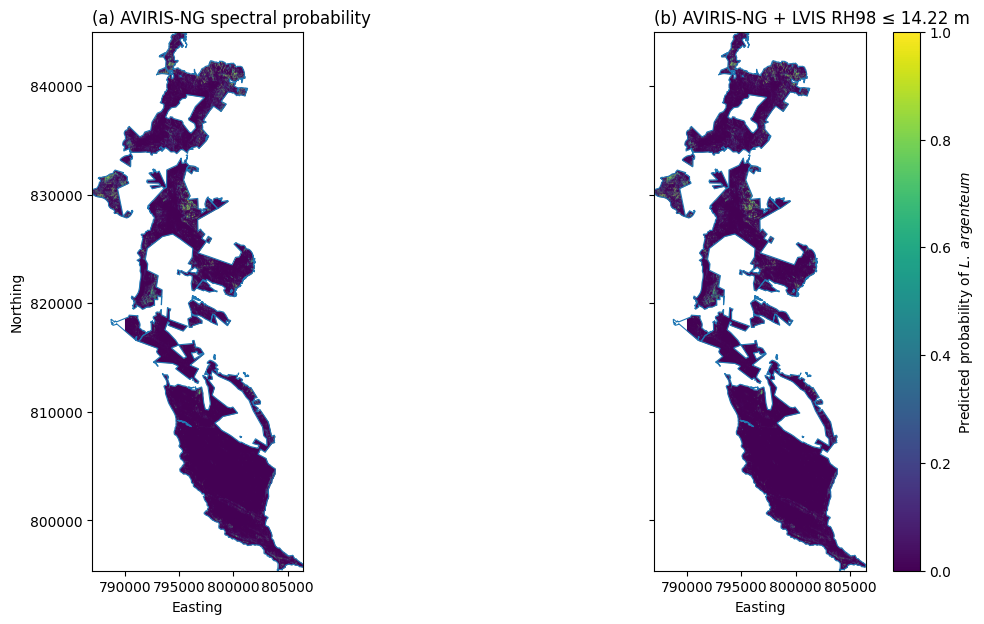

In [10]:
with rasterio.open(
    clipped_probability_path
) as source:

    spectral_map = source.read(
        1,
        masked=True,
    )

    map_bounds = source.bounds
    map_crs = source.crs


with rasterio.open(
    filtered_probability_path
) as source:

    filtered_map = source.read(
        1,
        masked=True,
    )


tmnp_map = (
    tmnp
    .to_crs(
        map_crs
    )
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        14,
        7,
    ),
    sharex=True,
    sharey=True,
)


for axis, raster_data, title in [
    (
        axes[0],
        spectral_map,
        "(a) AVIRIS-NG spectral probability",
    ),
    (
        axes[1],
        filtered_map,
        (
            "(b) AVIRIS-NG + LVIS "
            f"RH98 ≤ {structural_upper_bound_m:.2f} m"
        ),
    ),
]:

    image = axis.imshow(
        raster_data,
        extent=[
            map_bounds.left,
            map_bounds.right,
            map_bounds.bottom,
            map_bounds.top,
        ],
        origin="upper",
        cmap="viridis",
        vmin=0,
        vmax=1,
    )

    tmnp_map.boundary.plot(
        ax=axis,
        linewidth=0.8,
    )

    axis.set_title(
        title,
        loc="left",
    )

    axis.set_xlabel(
        "Easting"
    )


axes[0].set_ylabel(
    "Northing"
)


colourbar = fig.colorbar(
    image,
    ax=axes,
    fraction=0.025,
    pad=0.025,
)

colourbar.set_label(
    "Predicted probability of $L.$ $argenteum$"
)


fig.savefig(
    figure_dir
    / "F_AVIRIS_vs_LVIS_structurally_filtered_probability.png",
    dpi=400,
    bbox_inches="tight",
)

plt.show()


## 9. Inspect the final TMNP probability raster

This diagnostic figure is drawn directly from the clipped GeoTIFF. Any remaining gaps therefore represent missing/invalid AVIRIS-NG coverage rather than LVIS coverage.

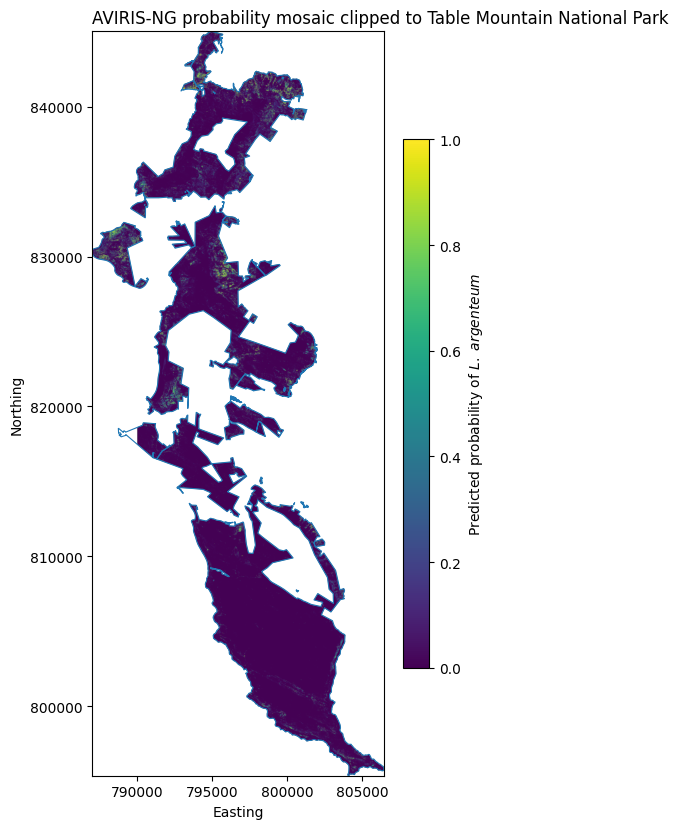

In [11]:
with rasterio.open(
    clipped_probability_path
) as source:

    probability_for_plot = source.read(
        1,
        masked=True,
    )

    plot_bounds = source.bounds
    plot_crs = source.crs

tmnp_plot = tmnp.to_crs(
    plot_crs
)

fig, ax = plt.subplots(
    figsize=(8.4, 8.4)
)

image = ax.imshow(
    probability_for_plot,
    extent=[
        plot_bounds.left,
        plot_bounds.right,
        plot_bounds.bottom,
        plot_bounds.top,
    ],
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

tmnp_plot.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

colourbar.set_label(
    "Predicted probability of $L.$ $argenteum$"
)

ax.set_title(
    "AVIRIS-NG probability mosaic clipped to Table Mountain National Park",
    loc="left",
)

ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

fig.tight_layout()

fig.savefig(
    figure_dir
    / "F_TMNP_probability_map.png",
    dpi=400,
)

plt.show()

# Part B — Independent GBIF occurrence evaluation

## 10. Create a 5 m UTM validation raster

All distance buffers are measured in metres. Nearest-neighbour reprojection preserves the original classifier probabilities rather than interpolating new values.

In [12]:
validation_raster_path = (
    raster_dir
    / "Larg_probability_TMNP_UTM34S_5m_validation.tif"
)

with rasterio.open(
    clipped_probability_path
) as source:

    validation_crs = CRS.from_string(
        working_crs
    )

    same_crs = (
        source.crs
        == validation_crs
    )

    same_resolution = np.isclose(
        abs(source.transform.a),
        validation_resolution_m,
    )

    if same_crs and same_resolution:

        validation_probability = (
            source.read(
                1,
                masked=True,
            )
            .filled(np.nan)
            .astype("float32")
        )

        validation_transform = source.transform
        validation_profile = source.profile.copy()

    else:

        (
            validation_transform,
            validation_width,
            validation_height,
        ) = calculate_default_transform(
            source.crs,
            validation_crs,
            source.width,
            source.height,
            *source.bounds,
            resolution=validation_resolution_m,
        )

        validation_probability = np.full(
            (
                validation_height,
                validation_width,
            ),
            np.nan,
            dtype="float32",
        )

        reproject(
            source=rasterio.band(
                source,
                1,
            ),
            destination=validation_probability,
            src_transform=source.transform,
            src_crs=source.crs,
            src_nodata=source.nodata,
            dst_transform=validation_transform,
            dst_crs=validation_crs,
            dst_nodata=np.nan,
            resampling=Resampling.nearest,
        )

        validation_profile = source.profile.copy()

        validation_profile.update({
            "crs": validation_crs,
            "transform": validation_transform,
            "width": validation_width,
            "height": validation_height,
        })

validation_profile.update({
    "dtype": "float32",
    "nodata": np.nan,
    "compress": "LZW",
})

with rasterio.open(
    validation_raster_path,
    "w",
    **validation_profile,
) as destination:

    destination.write(
        validation_probability,
        1,
    )

print(f"Validation raster: {validation_raster_path}")
print(
    f"Valid pixels: "
    f"{np.isfinite(validation_probability).sum():,}"
)

Validation raster: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_UTM34S_5m_validation.tif
Valid pixels: 8,894,460


## 11. Load the GBIF occurrence records

GeoPackage, shapefile, GeoJSON and CSV inputs are accepted. CSV files use common GBIF coordinate fields such as `decimalLongitude` and `decimalLatitude`.

In [13]:
longitude_candidates = (
    "decimalLongitude",
    "longitude",
    "Longitude",
    "lon",
    "X",
)

latitude_candidates = (
    "decimalLatitude",
    "latitude",
    "Latitude",
    "lat",
    "Y",
)

species_candidates = (
    "species",
    "scientificName",
    "Scientific.Names",
    "Species",
)


def first_present(columns, candidates):
    lower_lookup = {
        str(column).lower(): column
        for column in columns
    }

    for candidate in candidates:

        if candidate in columns:
            return candidate

        if candidate.lower() in lower_lookup:
            return lower_lookup[
                candidate.lower()
            ]

    return None


occurrence_frames = []


for pattern in [
    "*.gpkg",
    "*.shp",
    "*.geojson",
]:

    for file_path in sorted(
        gbif_dir.glob(pattern)
    ):

        if file_path.suffix.lower() == ".gpkg":

            layer_names = (
                gpd.list_layers(
                    file_path
                )["name"]
                .tolist()
            )

        else:

            layer_names = [
                None
            ]

        for layer_name in layer_names:

            occurrence_layer = (
                gpd.read_file(
                    file_path,
                    layer=layer_name,
                )
                if layer_name is not None
                else gpd.read_file(
                    file_path
                )
            )

            if occurrence_layer.empty:
                continue

            if occurrence_layer.crs is None:
                raise ValueError(
                    f"{file_path.name} has no CRS."
                )

            occurrence_layer[
                "source_file"
            ] = file_path.name

            occurrence_frames.append(
                occurrence_layer.to_crs(
                    "EPSG:4326"
                )
            )


for file_path in sorted(
    gbif_dir.glob("*.csv")
):

    occurrence_table = pd.read_csv(
        file_path
    )

    longitude_column = first_present(
        occurrence_table.columns,
        longitude_candidates,
    )

    latitude_column = first_present(
        occurrence_table.columns,
        latitude_candidates,
    )

    if (
        longitude_column is None
        or latitude_column is None
    ):
        continue

    occurrence_table[
        longitude_column
    ] = pd.to_numeric(
        occurrence_table[
            longitude_column
        ],
        errors="coerce",
    )

    occurrence_table[
        latitude_column
    ] = pd.to_numeric(
        occurrence_table[
            latitude_column
        ],
        errors="coerce",
    )

    occurrence_table = occurrence_table.dropna(
        subset=[
            longitude_column,
            latitude_column,
        ]
    )

    occurrence_layer = gpd.GeoDataFrame(
        occurrence_table,
        geometry=gpd.points_from_xy(
            occurrence_table[
                longitude_column
            ],
            occurrence_table[
                latitude_column
            ],
        ),
        crs="EPSG:4326",
    )

    occurrence_layer[
        "source_file"
    ] = file_path.name

    occurrence_frames.append(
        occurrence_layer
    )


if not occurrence_frames:
    raise FileNotFoundError(
        f"No readable occurrence layers were found in:\n{gbif_dir}"
    )

gbif = gpd.GeoDataFrame(
    pd.concat(
        occurrence_frames,
        ignore_index=True,
    ),
    crs="EPSG:4326",
)

gbif_species_column = first_present(
    gbif.columns,
    species_candidates,
)

if gbif_species_column is not None:

    target_rows = (
        gbif[
            gbif_species_column
        ]
        .astype(str)
        .str.strip()
        == target_species
    )

    if target_rows.any():

        gbif = (
            gbif.loc[
                target_rows
            ]
            .copy()
        )

uncertainty_column = first_present(
    gbif.columns,
    (
        "coordinateUncertaintyInMeters",
        "coordinate_uncertainty",
        "uncertainty",
    ),
)

if (
    uncertainty_column is not None
    and maximum_coordinate_uncertainty_m is not None
):

    uncertainty = pd.to_numeric(
        gbif[
            uncertainty_column
        ],
        errors="coerce",
    )

    acceptable_uncertainty = (
        uncertainty.isna()
        | (
            uncertainty
            <= maximum_coordinate_uncertainty_m
        )
    )

    gbif = (
        gbif.loc[
            acceptable_uncertainty
        ]
        .copy()
    )

gbif = (
    gbif
    .to_crs(
        working_crs
    )
    .reset_index(drop=True)
)

print(
    f"GBIF records after species/uncertainty filtering: "
    f"{len(gbif):,}"
)

GBIF records after species/uncertainty filtering: 1,173


## 12. Restrict GBIF to the mapped TMNP domain and one record per 5 m pixel

In [14]:
tmnp_utm = tmnp.to_crs(
    working_crs
)

gbif = gpd.sjoin(
    gbif,
    tmnp_utm[
        ["geometry"]
    ],
    how="inner",
    predicate="within",
).drop(
    columns=[
        "index_right"
    ],
    errors="ignore",
)

gbif_rows, gbif_columns = rasterio.transform.rowcol(
    validation_transform,
    gbif.geometry.x,
    gbif.geometry.y,
)

gbif[
    "raster_row"
] = np.asarray(
    gbif_rows,
    dtype=int,
)

gbif[
    "raster_column"
] = np.asarray(
    gbif_columns,
    dtype=int,
)

inside_raster = (
    (gbif["raster_row"] >= 0)
    & (gbif["raster_row"] < validation_probability.shape[0])
    & (gbif["raster_column"] >= 0)
    & (gbif["raster_column"] < validation_probability.shape[1])
)

gbif = (
    gbif.loc[
        inside_raster
    ]
    .copy()
)

gbif[
    "probability_exact"
] = validation_probability[
    gbif[
        "raster_row"
    ].to_numpy(),
    gbif[
        "raster_column"
    ].to_numpy(),
]

gbif = (
    gbif.loc[
        np.isfinite(
            gbif[
                "probability_exact"
            ]
        )
    ]
    .drop_duplicates(
        subset=[
            "raster_row",
            "raster_column",
        ]
    )
    .reset_index(drop=True)
)

print(
    f"Unique GBIF pixels inside mapped TMNP AVIRIS-NG coverage: "
    f"{len(gbif):,}"
)

Unique GBIF pixels inside mapped TMNP AVIRIS-NG coverage: 702


## 13. Independence filter

Where the target-species training coordinates are available, GBIF records within 30 m of a training point are removed before validation.

In [15]:
if training_points_csv.exists():

    training_points = pd.read_csv(
        training_points_csv
    )

    training_species_column = first_present(
        training_points.columns,
        species_candidates,
    )

    training_longitude_column = first_present(
        training_points.columns,
        longitude_candidates,
    )

    training_latitude_column = first_present(
        training_points.columns,
        latitude_candidates,
    )

    if (
        training_species_column is not None
        and training_longitude_column is not None
        and training_latitude_column is not None
    ):

        target_training = training_points.loc[
            training_points[
                training_species_column
            ].astype(str)
            == target_species
        ].copy()

        target_training[
            training_longitude_column
        ] = pd.to_numeric(
            target_training[
                training_longitude_column
            ],
            errors="coerce",
        )

        target_training[
            training_latitude_column
        ] = pd.to_numeric(
            target_training[
                training_latitude_column
            ],
            errors="coerce",
        )

        target_training = target_training.dropna(
            subset=[
                training_longitude_column,
                training_latitude_column,
            ]
        )

        target_training = gpd.GeoDataFrame(
            target_training,
            geometry=gpd.points_from_xy(
                target_training[
                    training_longitude_column
                ],
                target_training[
                    training_latitude_column
                ],
            ),
            crs="EPSG:4326",
        ).to_crs(
            working_crs
        )

        if len(target_training) > 0:

            training_tree = cKDTree(
                np.column_stack([
                    target_training.geometry.x,
                    target_training.geometry.y,
                ])
            )

            gbif_xy = np.column_stack([
                gbif.geometry.x,
                gbif.geometry.y,
            ])

            distance_to_training_m, _ = training_tree.query(
                gbif_xy,
                k=1,
            )

            gbif[
                "distance_to_nearest_training_m"
            ] = distance_to_training_m

            independent = (
                distance_to_training_m
                > training_exclusion_m
            )

            print(
                f"Removed {(~independent).sum():,} GBIF pixels within "
                f"{training_exclusion_m:.0f} m of a target training point."
            )

            gbif = (
                gbif.loc[
                    independent
                ]
                .copy()
                .reset_index(drop=True)
            )

else:

    print(
        "Training-point file not found. "
        "The spatial independence filter cannot be applied."
    )

if len(gbif) == 0:
    raise RuntimeError(
        "No independent GBIF occurrence pixels remain."
    )

print(
    f"Independent GBIF occurrence pixels retained: "
    f"{len(gbif):,}"
)

Removed 58 GBIF pixels within 30 m of a target training point.
Independent GBIF occurrence pixels retained: 644


## 14. Test direct overlap with P > 0.70 and positional-error sensitivity

The 0 m row is the strict result requested: the proportion of GBIF occurrences whose **same raster pixel** has P > 0.70.

The 10, 20 and 30 m rows use the maximum probability inside a circular neighbourhood and are reported only as sensitivity analyses.

In [16]:
def circular_footprint(radius_pixels):
    radius_pixels = int(
        radius_pixels
    )

    if radius_pixels == 0:
        return np.ones(
            (1, 1),
            dtype=bool,
        )

    y_coordinates, x_coordinates = np.mgrid[
        -radius_pixels:radius_pixels + 1,
        -radius_pixels:radius_pixels + 1,
    ]

    return (
        x_coordinates ** 2
        + y_coordinates ** 2
        <= radius_pixels ** 2
    )


validation_rows = (
    gbif[
        "raster_row"
    ]
    .to_numpy(int)
)

validation_columns = (
    gbif[
        "raster_column"
    ]
    .to_numpy(int)
)

validation_summary_rows = []


for radius_m in buffer_radii_m:

    radius_pixels = int(
        np.ceil(
            radius_m
            / validation_resolution_m
        )
    )

    if radius_pixels == 0:

        local_maximum_probability = (
            validation_probability
        )

    else:

        probability_for_filter = np.where(
            np.isfinite(
                validation_probability
            ),
            validation_probability,
            -np.inf,
        )

        local_maximum_probability = ndimage.maximum_filter(
            probability_for_filter,
            footprint=circular_footprint(
                radius_pixels
            ),
            mode="constant",
            cval=-np.inf,
        )

        local_maximum_probability[
            ~np.isfinite(
                local_maximum_probability
            )
        ] = np.nan

    occurrence_probability = local_maximum_probability[
        validation_rows,
        validation_columns,
    ]

    gbif[
        f"max_probability_{radius_m}m"
    ] = occurrence_probability

    above_threshold = (
        occurrence_probability
        > probability_threshold
    )

    gbif[
        f"above_070_{radius_m}m"
    ] = above_threshold

    validation_summary_rows.append({
        "buffer_m": radius_m,
        "n_occurrences": len(
            occurrence_probability
        ),
        "n_above_0_70": int(
            above_threshold.sum()
        ),
        "proportion_above_0_70": float(
            above_threshold.mean()
        ),
        "median_probability": float(
            np.nanmedian(
                occurrence_probability
            )
        ),
        "mean_probability": float(
            np.nanmean(
                occurrence_probability
            )
        ),
    })


validation_summary = pd.DataFrame(
    validation_summary_rows
)

print(
    validation_summary
    .round(4)
    .to_string(index=False)
)

strict_result = validation_summary.loc[
    validation_summary[
        "buffer_m"
    ] == 0
].iloc[0]

print(
    f"\nSTRICT COINCIDENT-PIXEL RESULT:\n"
    f"{int(strict_result['n_above_0_70'])} of "
    f"{int(strict_result['n_occurrences'])} independent GBIF occurrences "
    f"({strict_result['proportion_above_0_70']:.1%}) fall directly on "
    f"pixels with P > {probability_threshold:.2f}."
)

 buffer_m  n_occurrences  n_above_0_70  proportion_above_0_70  median_probability  mean_probability
        0            644            55                 0.0854              0.0139            0.1511
       10            644           280                 0.4348              0.5926            0.5163
       20            644           453                 0.7034              0.8924            0.7235
       30            644           533                 0.8276              0.9577            0.8328

STRICT COINCIDENT-PIXEL RESULT:
55 of 644 independent GBIF occurrences (8.5%) fall directly on pixels with P > 0.70.


## 15. Compare occurrence probabilities with random mapped TMNP pixels

Because GBIF is presence-only, a background comparison is more informative than pretending the unsampled park is a verified absence layer.

`enrichment` is the occurrence hit rate at P > 0.70 divided by the fraction of mapped TMNP background pixels above the same threshold. The rank AUC is the probability that an occurrence pixel receives a higher model score than a randomly selected mapped background pixel.

In [17]:
valid_background_rows, valid_background_columns = np.where(
    np.isfinite(
        validation_probability
    )
)

if len(valid_background_rows) > background_sample_size:

    background_selection = random_generator.choice(
        len(valid_background_rows),
        size=background_sample_size,
        replace=False,
    )

    background_rows = valid_background_rows[
        background_selection
    ]

    background_columns = valid_background_columns[
        background_selection
    ]

else:

    background_rows = valid_background_rows
    background_columns = valid_background_columns


background_probability = validation_probability[
    background_rows,
    background_columns,
]

background_threshold_rate = float(
    (
        background_probability
        > probability_threshold
    ).mean()
)


def rank_auc(presence_probability, background_probability):

    presence_probability = np.asarray(
        presence_probability,
        dtype=float,
    )

    background_probability = np.asarray(
        background_probability,
        dtype=float,
    )

    presence_probability = presence_probability[
        np.isfinite(
            presence_probability
        )
    ]

    background_probability = background_probability[
        np.isfinite(
            background_probability
        )
    ]

    combined = np.concatenate([
        presence_probability,
        background_probability,
    ])

    ranks = pd.Series(
        combined
    ).rank(
        method="average"
    ).to_numpy()

    n_presence = len(
        presence_probability
    )

    n_background = len(
        background_probability
    )

    rank_sum_presence = ranks[
        :n_presence
    ].sum()

    auc = (
        rank_sum_presence
        - n_presence
        * (
            n_presence + 1
        )
        / 2
    ) / (
        n_presence
        * n_background
    )

    return float(
        auc
    )


background_comparison_rows = []


for radius_m in buffer_radii_m:

    occurrence_probability = (
        gbif[
            f"max_probability_{radius_m}m"
        ]
        .to_numpy(float)
    )

    occurrence_hit_rate = float(
        (
            occurrence_probability
            > probability_threshold
        ).mean()
    )

    enrichment = (
        occurrence_hit_rate
        / background_threshold_rate
        if background_threshold_rate > 0
        else np.nan
    )

    background_comparison_rows.append({
        "buffer_m": radius_m,
        "occurrence_hit_rate_Pgt070": occurrence_hit_rate,
        "background_rate_Pgt070": background_threshold_rate,
        "enrichment": enrichment,
        "median_occurrence_probability": float(
            np.nanmedian(
                occurrence_probability
            )
        ),
        "median_background_probability": float(
            np.nanmedian(
                background_probability
            )
        ),
        "presence_background_rank_AUC": rank_auc(
            occurrence_probability,
            background_probability,
        ),
    })


background_comparison = pd.DataFrame(
    background_comparison_rows
)

print(
    background_comparison
    .round(4)
    .to_string(index=False)
)

 buffer_m  occurrence_hit_rate_Pgt070  background_rate_Pgt070  enrichment  median_occurrence_probability  median_background_probability  presence_background_rank_AUC
        0                      0.0854                  0.0166      5.1603                         0.0139                         0.0022                        0.7470
       10                      0.4348                  0.0166     26.2709                         0.5926                         0.0022                        0.9413
       20                      0.7034                  0.0166     42.5025                         0.8924                         0.0022                        0.9752
       30                      0.8276                  0.0166     50.0084                         0.9577                         0.0022                        0.9879


## 16. Save validation outputs

The occurrence-level CSV and GeoPackage retain each independent record's exact-pixel probability and neighbourhood maxima so the validation can be checked directly in QGIS.

In [18]:
validation_summary.to_csv(
    table_dir
    / "T_GBIF_threshold_validation.csv",
    index=False,
)

background_comparison.to_csv(
    table_dir
    / "T_GBIF_background_comparison.csv",
    index=False,
)

gbif_for_csv = gbif.copy()

gbif_for_csv[
    "x_utm"
] = gbif_for_csv.geometry.x

gbif_for_csv[
    "y_utm"
] = gbif_for_csv.geometry.y

gbif_for_csv.drop(
    columns="geometry",
).to_csv(
    table_dir
    / "T_GBIF_occurrence_probabilities.csv",
    index=False,
)

gbif.to_file(
    output_dir
    / "GBIF_occurrences_with_probabilities.gpkg",
    layer="independent_occurrences",
    driver="GPKG",
)

print(
    "Occurrence-level and summary validation outputs written."
)

Occurrence-level and summary validation outputs written.


## 17. Final validation map

The map colours GBIF points according to the **strict coincident pixel** result. Buffered results remain separate in the sensitivity table.

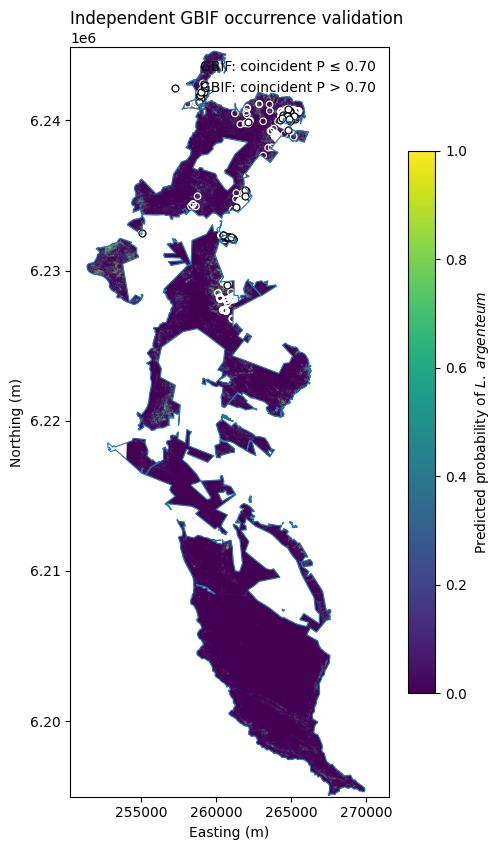

In [19]:
with rasterio.open(
    validation_raster_path
) as source:

    validation_plot = source.read(
        1,
        masked=True,
    )

    validation_bounds = source.bounds
    validation_plot_crs = source.crs

tmnp_validation = tmnp.to_crs(
    validation_plot_crs
)

gbif_validation = gbif.to_crs(
    validation_plot_crs
)

strict_high = (
    gbif_validation[
        "probability_exact"
    ]
    > probability_threshold
)

fig, ax = plt.subplots(
    figsize=(8.6, 8.6)
)

image = ax.imshow(
    validation_plot,
    extent=[
        validation_bounds.left,
        validation_bounds.right,
        validation_bounds.bottom,
        validation_bounds.top,
    ],
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

tmnp_validation.boundary.plot(
    ax=ax,
    linewidth=0.8,
)

gbif_validation.loc[
    ~strict_high
].plot(
    ax=ax,
    marker="o",
    markersize=22,
    facecolor="none",
    edgecolor="white",
    linewidth=0.9,
    label="GBIF: coincident P ≤ 0.70",
)

gbif_validation.loc[
    strict_high
].plot(
    ax=ax,
    marker="o",
    markersize=25,
    facecolor="white",
    edgecolor="black",
    linewidth=0.9,
    label="GBIF: coincident P > 0.70",
)

colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

colourbar.set_label(
    "Predicted probability of $L.$ $argenteum$"
)

ax.legend(
    frameon=False,
    loc="upper right",
)

ax.set_title(
    "Independent GBIF occurrence validation",
    loc="left",
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

fig.tight_layout()

fig.savefig(
    figure_dir
    / "F_GBIF_occurrence_validation.png",
    dpi=400,
)

plt.show()

## 18. Headline results

The final cell writes a compact text file from the results calculated above.

In [20]:
strict_validation = validation_summary.loc[
    validation_summary[
        "buffer_m"
    ] == 0
].iloc[0]

headline_validation = validation_summary.loc[
    validation_summary[
        "buffer_m"
    ] == headline_buffer_m
].iloc[0]

headline_background = background_comparison.loc[
    background_comparison[
        "buffer_m"
    ] == headline_buffer_m
].iloc[0]

headline_text = f"""
AVIRIS-NG probability mapping and GBIF occurrence validation

Retained AVIRIS-NG bands: {expected_retained_bands}
Target species: {target_species}
Classifier: XGBoost
PCA components: {n_pcs}
Operational threshold: P > {probability_threshold:.2f}

AVIRIS-NG Level-3 tiles predicted: {len(probability_tile_paths)}
Full probability mosaic: {full_mosaic_path}
TMNP-clipped probability raster: {clipped_probability_path}
Binary candidate raster: {candidate_raster_path}

Independent mapped GBIF occurrence pixels: {len(gbif)}

Strict coincident-pixel result:
{int(strict_validation['n_above_0_70'])} of {int(strict_validation['n_occurrences'])}
({strict_validation['proportion_above_0_70']:.1%})
occur directly on pixels with P > {probability_threshold:.2f}.

{headline_buffer_m:.0f} m sensitivity:
{int(headline_validation['n_above_0_70'])} of {int(headline_validation['n_occurrences'])}
({headline_validation['proportion_above_0_70']:.1%})
have a P > {probability_threshold:.2f} pixel within {headline_buffer_m:.0f} m.

Enrichment over mapped TMNP background at {headline_buffer_m:.0f} m:
{headline_background['enrichment']:.2f}x

Presence-background rank AUC:
{headline_background['presence_background_rank_AUC']:.3f}

GBIF is presence-only. These statistics evaluate whether known localities
are concentrated in high-probability parts of the mapped domain. They are
not an absence-based estimate of classification accuracy.
""".strip()

headline_path = (
    output_dir
    / "headline_mapping_validation_results.txt"
)

headline_path.write_text(
    headline_text,
    encoding="utf-8",
)

print(
    headline_text
)

print(
    f"\nWritten: {headline_path}"
)

AVIRIS-NG probability mapping and GBIF occurrence validation

Retained AVIRIS-NG bands: 324
Target species: Leucadendron argenteum
Classifier: XGBoost
PCA components: 10
Operational threshold: P > 0.70

AVIRIS-NG Level-3 tiles predicted: 14
Full probability mosaic: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_AVIRIS_full_mosaic.tif
TMNP-clipped probability raster: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_clipped.tif
Binary candidate raster: /Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_candidate_pixels_Pgt070_TMNP.tif

Independent mapped GBIF occurrence pixels: 644

Strict coincident-pixel result:
55 of 644
(8.5%)
occur directly on pixels with P > 0.70.

20 m sensitivity:
453 of 644
(70.3%)
have a P > 0.70 pixel within 20 m.

Enrichment over mapped TMNP background at 20 m:
42.50x

Presence-background rank AUC:
0.975

# Part C — Validate the final AVIRIS-NG + LVIS map

The preceding GBIF analysis evaluated the unfiltered AVIRIS-NG probability
surface as a spectral baseline.

This section repeats the same occurrence evaluation using the **final
structurally filtered map**. The GBIF records, training-point exclusion,
probability threshold, buffer radii and random-background locations are
unchanged. This gives a direct before/after comparison of what the
field-informed LVIS structural rule does to the independent occurrence
evidence.

The structural threshold is inherited from the RH98 analysis rather than
hard-coded here. The main quantity remains the strict coincident-pixel result:
the proportion of independent GBIF localities whose final mapped probability
exceeds 0.70.


In [21]:
# ---------------------------------------------------------------------
# Reproject the final structurally filtered raster to the same 5 m UTM
# validation grid used for the spectral baseline.
# ---------------------------------------------------------------------

filtered_validation_probability = np.full(
    validation_probability.shape,
    np.nan,
    dtype="float32",
)


with rasterio.open(
    filtered_probability_path
) as filtered_source:

    reproject(
        source=rasterio.band(
            filtered_source,
            1,
        ),
        destination=filtered_validation_probability,
        src_transform=filtered_source.transform,
        src_crs=filtered_source.crs,
        src_nodata=filtered_source.nodata,
        dst_transform=validation_transform,
        dst_crs=CRS.from_string(
            working_crs
        ),
        dst_nodata=np.nan,
        resampling=Resampling.nearest,
    )


# ---------------------------------------------------------------------
# Validate independent GBIF occurrence locations against the final map.
# ---------------------------------------------------------------------

# Use the same independent occurrence pixel indices created in Part B.
filtered_validation_summary_rows = []


for radius_m in buffer_radii_m:

    radius_pixels = int(
        np.ceil(
            radius_m
            / validation_resolution_m
        )
    )


    if radius_pixels == 0:

        probability_surface = (
            filtered_validation_probability
        )

    else:

        footprint = circular_footprint(
            radius_pixels
        )

        probability_for_filter = np.where(
            np.isfinite(
                filtered_validation_probability
            ),
            filtered_validation_probability,
            -np.inf,
        )

        probability_surface = ndimage.maximum_filter(
            probability_for_filter,
            footprint=footprint,
            mode="constant",
            cval=-np.inf,
        )

        probability_surface[
            ~np.isfinite(
                probability_surface
            )
        ] = np.nan


    occurrence_probability = probability_surface[
        validation_rows,
        validation_columns,
    ]


    gbif[
        f"filtered_max_probability_{radius_m}m"
    ] = occurrence_probability


    above_threshold = (
        occurrence_probability
        > probability_threshold
    )


    gbif[
        f"filtered_above_{probability_threshold:.2f}_{radius_m}m"
    ] = above_threshold


    filtered_validation_summary_rows.append({
        "map": (
            "AVIRIS + LVIS "
            f"RH98 <= {structural_upper_bound_m:.2f} m"
        ),
        "buffer_m": radius_m,
        "n_occurrences": len(
            occurrence_probability
        ),
        "n_above_0_70": int(
            above_threshold.sum()
        ),
        "proportion_above_0_70": float(
            above_threshold.mean()
        ),
        "median_probability": float(
            np.nanmedian(
                occurrence_probability
            )
        ),
        "mean_probability": float(
            np.nanmean(
                occurrence_probability
            )
        ),
    })


filtered_validation_summary = pd.DataFrame(
    filtered_validation_summary_rows
)


# ---------------------------------------------------------------------
# Compare the exact same background pixels with the filtered map.
# ---------------------------------------------------------------------

filtered_background_probability = (
    filtered_validation_probability[
        background_rows,
        background_columns,
    ]
)


filtered_background_threshold_rate = float(
    (
        filtered_background_probability
        > probability_threshold
    ).mean()
)


filtered_background_comparison_rows = []


for radius_m in buffer_radii_m:

    occurrence_probability = (
        gbif[
            f"filtered_max_probability_{radius_m}m"
        ]
        .to_numpy(float)
    )


    occurrence_threshold_rate = float(
        (
            occurrence_probability
            > probability_threshold
        ).mean()
    )


    enrichment = (
        occurrence_threshold_rate
        / filtered_background_threshold_rate
        if filtered_background_threshold_rate > 0
        else np.nan
    )


    presence_background_auc = rank_auc(
        occurrence_probability,
        filtered_background_probability,
    )


    filtered_background_comparison_rows.append({
        "map": (
            "AVIRIS + LVIS "
            f"RH98 <= {structural_upper_bound_m:.2f} m"
        ),
        "buffer_m": radius_m,
        "occurrence_hit_rate_Pgt070": occurrence_threshold_rate,
        "background_rate_Pgt070": filtered_background_threshold_rate,
        "enrichment": enrichment,
        "median_occurrence_probability": float(
            np.nanmedian(
                occurrence_probability
            )
        ),
        "median_background_probability": float(
            np.nanmedian(
                filtered_background_probability
            )
        ),
        "presence_background_rank_AUC": presence_background_auc,
    })


filtered_background_comparison = pd.DataFrame(
    filtered_background_comparison_rows
)


# ---------------------------------------------------------------------
# Build one direct before/after table.
# ---------------------------------------------------------------------

spectral_validation_for_comparison = (
    validation_summary
    .copy()
)

spectral_validation_for_comparison[
    "map"
] = "AVIRIS spectral only"


combined_validation_summary = pd.concat(
    [
        spectral_validation_for_comparison,
        filtered_validation_summary,
    ],
    ignore_index=True,
)


spectral_background_for_comparison = (
    background_comparison
    .copy()
)

spectral_background_for_comparison[
    "map"
] = "AVIRIS spectral only"


combined_background_comparison = pd.concat(
    [
        spectral_background_for_comparison,
        filtered_background_comparison,
    ],
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Save validation tables.
# ---------------------------------------------------------------------

combined_validation_summary.to_csv(
    table_dir
    / "T_GBIF_validation_spectral_vs_LVIS_filtered.csv",
    index=False,
)


combined_background_comparison.to_csv(
    table_dir
    / "T_GBIF_background_spectral_vs_LVIS_filtered.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Display the final validation results.
# ---------------------------------------------------------------------

print(
    "\nIndependent occurrence validation:"
)

display(
    combined_validation_summary
)


print(
    "\nOccurrence versus background comparison:"
)

display(
    combined_background_comparison
)


Independent occurrence validation:


,buffer_m,n_occurrences,n_above_0_70,proportion_above_0_70,median_probability,mean_probability,map
0,0,644,55,0.085404,0.013930,0.151081,AVIRIS spectral only
1,10,644,280,0.434783,0.592624,0.516269,AVIRIS spectral only
2,20,644,453,0.703416,0.892395,0.723542,AVIRIS spectral only
3,30,644,533,0.827640,0.957684,0.832815,AVIRIS spectral only
4,0,644,54,0.083851,0.012797,0.146363,AVIRIS + LVIS RH98 <= 14.22 m
5,10,644,273,0.423913,0.568315,0.507853,AVIRIS + LVIS RH98 <= 14.22 m
6,20,644,448,0.695652,0.883549,0.715685,AVIRIS + LVIS RH98 <= 14.22 m
7,30,644,525,0.815217,0.955984,0.822320,AVIRIS + LVIS RH98 <= 14.22 m



Occurrence versus background comparison:


,buffer_m,occurrence_hit_rate_Pgt070,background_rate_Pgt070,enrichment,median_occurrence_probability,median_background_probability,presence_background_rank_AUC,map
0,0,0.085404,0.01655,5.160346,0.013930,0.002198,0.746969,AVIRIS spectral only
1,10,0.434783,0.01655,26.270852,0.592624,0.002198,0.941277,AVIRIS spectral only
2,20,0.703416,0.01655,42.502486,0.892395,0.002198,0.975245,AVIRIS spectral only
3,30,0.827640,0.01655,50.008444,0.957684,0.002198,0.987917,AVIRIS spectral only
4,0,0.083851,0.01445,5.802833,0.012797,0.001977,0.739576,AVIRIS + LVIS RH98 <= 14.22 m
5,10,0.423913,0.01445,29.336543,0.568315,0.001977,0.935758,AVIRIS + LVIS RH98 <= 14.22 m
6,20,0.695652,0.01445,48.142019,0.883549,0.001977,0.976113,AVIRIS + LVIS RH98 <= 14.22 m
7,30,0.815217,0.01445,56.416428,0.955984,0.001977,0.988217,AVIRIS + LVIS RH98 <= 14.22 m


## Final filtered-map occurrence figure

The map below is the actual AVIRIS-NG + LVIS product: probabilities come from
the 324-band XGBoost spectral model, while pixels with valid LVIS RH98 above
the field-informed structural upper bound have been vetoed.

GBIF points are classified using their **strict coincident pixel** on this
final raster. The numerical tables retain the 10–30 m positional-sensitivity
analyses.


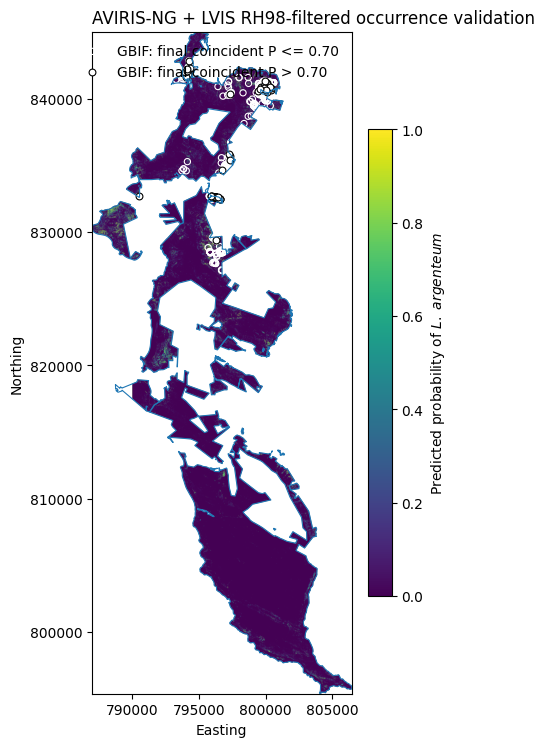

In [22]:
with rasterio.open(
    filtered_probability_path
) as source:

    final_filtered_plot = source.read(
        1,
        masked=True,
    )

    final_bounds = source.bounds
    final_crs = source.crs


tmnp_final = (
    tmnp
    .to_crs(
        final_crs
    )
)


gbif_final = (
    gbif
    .to_crs(
        final_crs
    )
)


strict_filtered_high = (
    gbif_final[
        "filtered_max_probability_0m"
    ]
    > probability_threshold
)


fig, ax = plt.subplots(
    figsize=(
        8.6,
        8.6,
    )
)


image = ax.imshow(
    final_filtered_plot,
    extent=[
        final_bounds.left,
        final_bounds.right,
        final_bounds.bottom,
        final_bounds.top,
    ],
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=1,
)


tmnp_final.boundary.plot(
    ax=ax,
    linewidth=0.8,
)


gbif_final.loc[
    ~strict_filtered_high
].plot(
    ax=ax,
    marker="o",
    markersize=20,
    facecolor="none",
    edgecolor="white",
    linewidth=0.8,
    label="GBIF: final coincident P <= 0.70",
)


gbif_final.loc[
    strict_filtered_high
].plot(
    ax=ax,
    marker="o",
    markersize=24,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8,
    label="GBIF: final coincident P > 0.70",
)


colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

colourbar.set_label(
    "Predicted probability of $L.$ $argenteum$"
)


ax.legend(
    frameon=False,
    loc="upper right",
)

ax.set_title(
    "AVIRIS-NG + LVIS RH98-filtered occurrence validation",
    loc="left",
)

ax.set_xlabel(
    "Easting"
)

ax.set_ylabel(
    "Northing"
)


fig.savefig(
    figure_dir
    / "F_GBIF_validation_AVIRIS_LVIS_filtered.png",
    dpi=400,
    bbox_inches="tight",
)

plt.show()


## Final mapping and validation headline

This last cell reports the final map rather than the spectral baseline. The values are calculated from the notebook outputs rather than typed manually.


In [23]:
strict_filtered = (
    filtered_validation_summary.loc[
        filtered_validation_summary[
            "buffer_m"
        ] == 0
    ]
    .iloc[0]
)


buffered_filtered = (
    filtered_validation_summary.loc[
        filtered_validation_summary[
            "buffer_m"
        ] == headline_buffer_m
    ]
    .iloc[0]
)


background_filtered = (
    filtered_background_comparison.loc[
        filtered_background_comparison[
            "buffer_m"
        ] == headline_buffer_m
    ]
    .iloc[0]
)


final_headline_text = f"""
FINAL AVIRIS-NG + LVIS OCCURRENCE MAP

Spectral model
--------------
AVIRIS-NG retained bands: {expected_retained_bands}
Classifier: XGBoost
PCA components: {n_pcs}

Structural filter
-----------------
LVIS product: mean RH98 on the 8 m footprint-scale grid
Tallest field-measured tree: {field_max_height_m:.2f} m
Paired LVIS-field RMSE: {lvis_field_rmse_m:.4f} m
Upper plausibility bound: RH98 <= {structural_upper_bound_m:.2f} m
Bound calculation: field maximum + 2 × paired RMSE
Pixels with valid RH98 above the bound are assigned probability 0.
Pixels without LVIS support retain their AVIRIS-NG probability.

Operational candidate threshold
-------------------------------
P > {probability_threshold:.2f}

Final probability raster
------------------------
{filtered_probability_path}

Final candidate raster
----------------------
{filtered_candidate_path}

Independent GBIF validation
---------------------------
Independent mapped occurrence pixels: {len(gbif)}

Strict coincident-pixel result:
{int(strict_filtered['n_above_0_70'])} of {int(strict_filtered['n_occurrences'])}
({strict_filtered['proportion_above_0_70']:.1%})
occur directly on final AVIRIS-NG + LVIS pixels with
P > {probability_threshold:.2f}.

{headline_buffer_m:.0f} m positional sensitivity:
{int(buffered_filtered['n_above_0_70'])} of {int(buffered_filtered['n_occurrences'])}
({buffered_filtered['proportion_above_0_70']:.1%})
have a final P > {probability_threshold:.2f} pixel within
{headline_buffer_m:.0f} m.

At {headline_buffer_m:.0f} m the occurrence hit rate is enriched by
{background_filtered['enrichment']:.2f} times relative to random mapped
TMNP background pixels.

Presence-background rank AUC:
{background_filtered['presence_background_rank_AUC']:.3f}
""".strip()


final_headline_path = (
    output_dir
    / "FINAL_AVIRIS_LVIS_mapping_validation_results.txt"
)


final_headline_path.write_text(
    final_headline_text,
    encoding="utf-8",
)


print(
    final_headline_text
)

print(
    f"\nWritten: {final_headline_path}"
)


FINAL AVIRIS-NG + LVIS OCCURRENCE MAP

Spectral model
--------------
AVIRIS-NG retained bands: 324
Classifier: XGBoost
PCA components: 10

Structural filter
-----------------
LVIS product: mean RH98 on the 8 m footprint-scale grid
Tallest field-measured tree: 10.20 m
Paired LVIS-field RMSE: 2.0086 m
Upper plausibility bound: RH98 <= 14.22 m
Bound calculation: field maximum + 2 × paired RMSE
Pixels with valid RH98 above the bound are assigned probability 0.
Pixels without LVIS support retain their AVIRIS-NG probability.

Operational candidate threshold
-------------------------------
P > 0.70

Final probability raster
------------------------
/Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif

Final candidate raster
----------------------
/Users/phemelo/Documents/LesHyperion/outputs/03_probability_mapping_validation/rasters/Larg_candidate_Pgt070_AVIRIS_LVIS_RH98_filtered_TMNP.tif

Independent GBIF va